In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pyodbc
import re
import math

In [2]:
server = 'localhost\\SQLEXPRESS'

database = 'HealthCareWarehouse'

connection_url = f'mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+server&Trusted_Connection=Yes'

engine = create_engine(connection_url)

In [3]:
db_tables = ['bronze.encounters_info','bronze.organizations_info','bronze.patients_info','bronze.payers_info','bronze.procedures_info']
df = {}
for i in db_tables:
    query = f'SELECT * FROM {i}'
    data = pd.read_sql(query,con=engine)
    df[i] = data



*************************************** Data Quality Report ****************************************



====================================== bronze.encounters_info ======================================
27891 Rows & 14 columns
++++++++++++++++++++++++++++++++++++++++++++++++++
0 rows are duplicate
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 27891 entries, 0 to 27890
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   encounter_id           27891 non-null  str           
 1   start                  27891 non-null  datetime64[us]
 2   stop                   27891 non-null  datetime64[us]
 3   patient_id             27891 non-null  str           
 4   organization_id        27891 non-null  str           
 5   payer_id               27891 non-null  str           
 6   encounter_class        27891 non-null  str           
 7   encounter_code

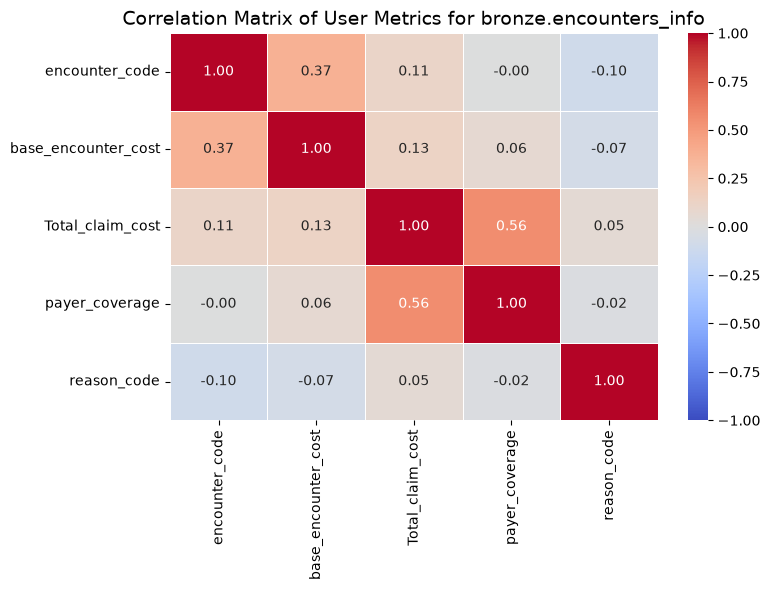




====================================== bronze.organizations_info ======================================
1 Rows & 8 columns
++++++++++++++++++++++++++++++++++++++++++++++++++
0 rows are duplicate
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   organization_id       1 non-null      str    
 1   organization_name     1 non-null      str    
 2   organization_address  1 non-null      str    
 3   organization_city     1 non-null      str    
 4   organization_state    1 non-null      str    
 5   organization_zip      1 non-null      int64  
 6   organization_lat      1 non-null      float64
 7   organization_lon      1 non-null      float64
dtypes: float64(2), int64(1), str(5)
memory usage: 196.0 bytes
None
--------------------------------------------------
                  count         m

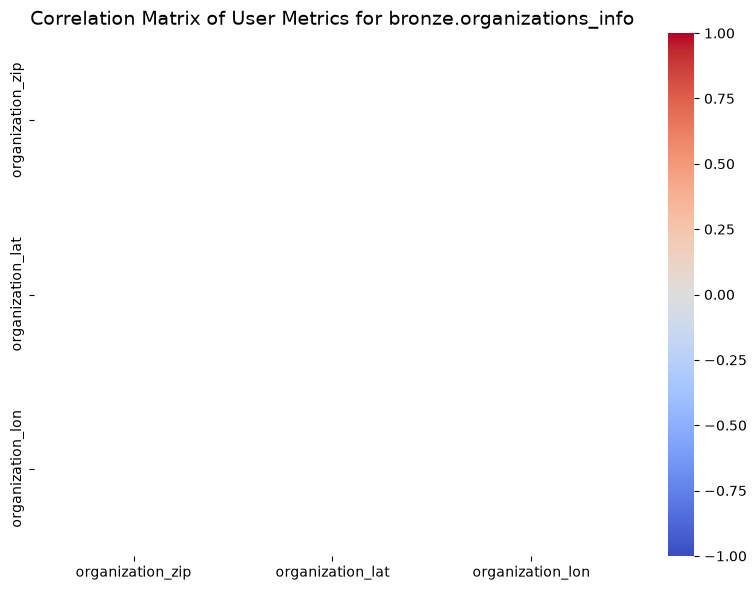




====================================== bronze.patients_info ======================================
974 Rows & 20 columns
++++++++++++++++++++++++++++++++++++++++++++++++++
0 rows are duplicate
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patients_id      974 non-null    str    
 1   birthdate        974 non-null    object 
 2   deathdate        154 non-null    object 
 3   prefix           974 non-null    str    
 4   first_name       974 non-null    str    
 5   last_name        974 non-null    str    
 6   suffix           21 non-null     str    
 7   maiden           386 non-null    str    
 8   marital_status   973 non-null    str    
 9   race             974 non-null    str    
 10  ethnicity        974 non-null    str    
 11  gender           974 non-null    str    
 12  birthplace

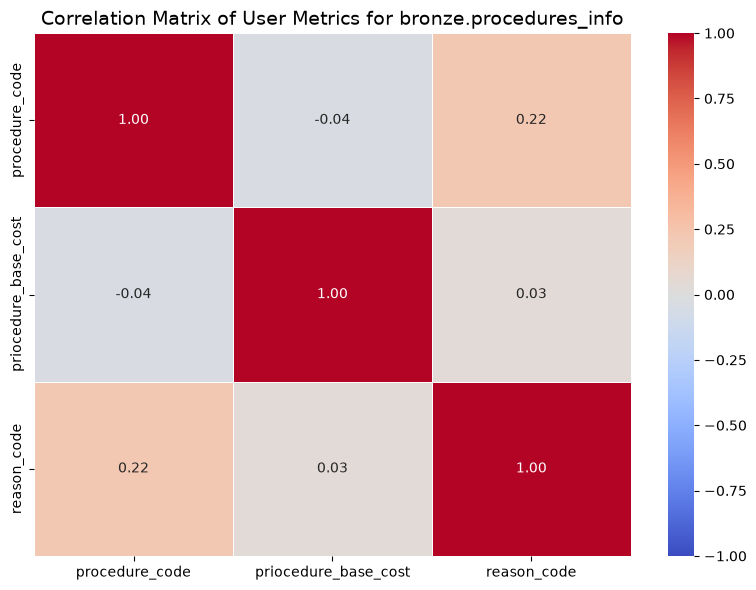

In [4]:
print('=' * 100)
print('*'*39 +' Data Quality Report ' + '*'*40)
print('=' * 100)

print('\n\n')
for i in db_tables:
    print('=' * 38 + f' {i} ' + '='*38)
    print(f'{df[i].shape[0]} Rows & {df[i].shape[1]} columns')
    print('+' * 50)
    duplicated=df[i].duplicated().sum()
    print(f"{duplicated} rows are duplicate")
    print('-' * 50)
    print(df[i].info())
    print('-' * 50)
    print(df[i].describe().T)
    print('-' * 50)
    missing_summary={
    "Missing Count": df[i].isna().sum(),
    "Missing Percentage" :df[i].isnull().mean() * 100
    }
    print(f'Missing Count:\n{missing_summary["Missing Count"]}\n\nMissing Percentage:\n{missing_summary["Missing Percentage"]}')
    print('-' * 50)
    print(f'Numbers of Unique Fields in {i}:\n{df[i].nunique()}')
    print('-' * 50)

    cols_to_drop = [col for col in df[i].columns if re.search(r'id$', str(col), re.IGNORECASE)]
    df_numeric = df[i].drop(columns=cols_to_drop).select_dtypes(include=['number'])
    
    # Safely plot correlation matrix only if numeric columns exist
    if not df_numeric.empty and df_numeric.shape[1] > 1:
        corr_matrix = df_numeric.corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, 
                    annot=True, 
                    cmap='coolwarm', 
                    vmin=-1, 
                    vmax=1, 
                    fmt=".2f",
                    linewidths=0.5)

        # Plot settings properly indented inside the loop
        plt.title(f'Correlation Matrix of User Metrics for {i}', fontsize=14)
        plt.tight_layout() 
        plt.show()
    else:
        print(f"Not enough numeric columns to generate a correlation matrix for {i}.")
                

    print('\n\n')
    
    